# Import packages

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop

# Processing data

In [10]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42


In [11]:
df = pd.read_csv("./data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)

In [12]:
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
print(df_filtered_one_genre.shape)
df_filtered_one_genre.head()

(8753, 31)


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult,genre_count
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1\n Beyond the hills\n Stay there!\n Voichita!...,Beyond the Hills (2012),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
23,"Sir, this place is so dusty.\n Hmm.\n Your cho...",Bhagavan Dasante Ramrajyam (2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
28,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",Bhairathi Ranagal (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [13]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


/tmp/ipykernel_71074/707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [14]:
df_filtered_one_genre['filtered_genre'].value_counts()


filtered_genre
imdb_drama          2948
imdb_comedy         1622
imdb_documentary    1301
imdb_horror          944
imdb_thriller        643
imdb_romance         262
imdb_action          242
imdb_western         112
imdb_family          112
imdb_sci-fi           79
imdb_crime            61
imdb_animation        56
imdb_talk-show        51
imdb_music            50
imdb_short            49
imdb_mystery          49
imdb_adventure        37
imdb_fantasy          27
imdb_reality-tv       21
imdb_musical          21
imdb_war              16
imdb_biography        16
imdb_sport            12
imdb_game-show         8
imdb_news              8
imdb_history           6
Name: count, dtype: int64

/tmp/ipykernel_71074/3269823211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")


Text(0, 0.5, 'Genres')

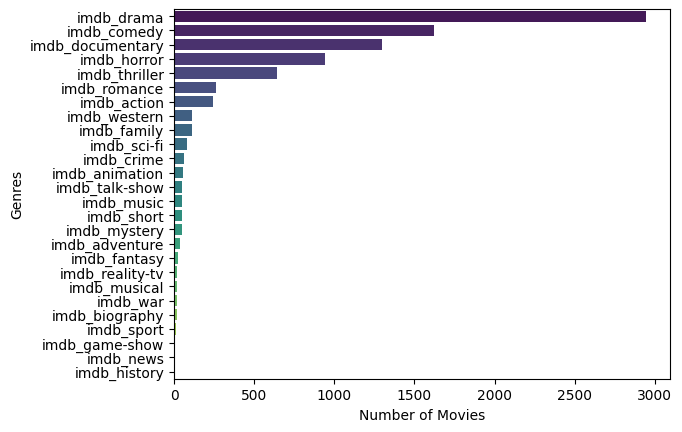

In [15]:

df_counts = df_filtered_one_genre['filtered_genre'].value_counts().reset_index()
df_counts.columns = ['Genre', 'Count']

sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")

plt.xlabel('Number of Movies')
plt.ylabel('Genres')


In [16]:
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])

In [17]:
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

for genre,number in sorted_list:
    print(f"Genre: {genre}, number of samples: {number}")

genre_to_keep = [genre for genre,_ in sorted_list]
genre_to_keep

Genre: imdb_drama, number of samples: 2948
Genre: imdb_comedy, number of samples: 1622
Genre: imdb_documentary, number of samples: 1301
Genre: imdb_horror, number of samples: 944
Genre: imdb_thriller, number of samples: 643
Genre: imdb_romance, number of samples: 262


['imdb_drama',
 'imdb_comedy',
 'imdb_documentary',
 'imdb_horror',
 'imdb_thriller',
 'imdb_romance']

In [18]:
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)
df_filtered_one_genre_to_train

,Script,filtered_genre
0,So what's goin' on?\n Where's my brother?\n So...,imdb_horror
1,"Like this?\n Good.\n Okay, that's good.\n Righ...",imdb_drama
2,1\n Beyond the hills\n Stay there!\n Voichita!...,imdb_drama
3,"Sir, this place is so dusty.\n Hmm.\n Your cho...",imdb_drama
4,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",imdb_drama
...,...,...
7715,"Here in Malaysia, there is an almost\n overwhe...",imdb_comedy
7716,"Okay, let's go for a take\n Get ready to carry...",imdb_drama
7717,Turn left.\n Make a right.\n Is this the kitch...,imdb_documentary
7718,Are you going somewhere? No?\n Last week I was...,imdb_drama


In [19]:
X_train,X_test , y_train,y_test = train_test_split(df_filtered_one_genre_to_train['Script'],df_filtered_one_genre_to_train['filtered_genre'],test_size=test_size,random_state=random_state)

In [20]:
minn = df_filtered_one_genre_to_train['filtered_genre'].value_counts().min()
list_equilibrate = []
for genre in df_filtered_one_genre_to_train['filtered_genre'].unique():
    list_equilibrate.append(df_filtered_one_genre_to_train.loc[df_filtered_one_genre_to_train['filtered_genre'] == genre].sample(minn))
df_equilbrate = pd.concat(list_equilibrate)
X_train_equilibrate,X_test_equilibrate , y_train_equilibrate,y_test_equilibrate = train_test_split(df_equilbrate['Script'],df_equilbrate['filtered_genre'],test_size=test_size,random_state=random_state)

# Training and testing

## MultinomialNB with unigram

In [14]:
def lemma_tokenize(doc):
    wnl = WordNetLemmatizer()
    return [wnl.lemmatize(t) for t in word_tokenize(doc)]

def char_tokenize(doc):
    return [char for char in doc]

def byte_tokenize(doc):
    tokens = doc.encode("utf-8")
    tokens = list(map(int, tokens))
    return [str(token) for token in tokens]

def gpt_tokenize(doc):
    enc = tiktoken.encoding_for_model("gpt-4")
    tokens = enc.encode(doc)
    return [str(token) for token in tokens]

In [ ]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB())

In [17]:
y_train.shape

(6176,)

In [ ]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report unbalanced:\n", classification_report(y_test, y_pred))

Features dimension: (6176, 200664)
Classification Report without equilibrate:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.82      0.85       251
      imdb_drama       0.65      0.72      0.69       609
     imdb_horror       0.65      0.56      0.60       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.62      0.36      0.46       138

        accuracy                           0.66      1544
       macro avg       0.70      0.56      0.60      1544
    weighted avg       0.67      0.66      0.65      1544



In [19]:
model_equilibrate = make_pipeline(CountVectorizer(ngram_range = (1,1)), MultinomialNB())

In [20]:
model_equilibrate.fit(X_train_equilibrate, y_train_equilibrate)


y_pred_equilibrate = model_equilibrate.predict(X_test_equilibrate)

print(f"Features dimension: {len(X_train_equilibrate), len(model_equilibrate[0].vocabulary_)}")
print("Classification Report balanced:\n", classification_report(y_test_equilibrate, y_pred_equilibrate))

Features dimension: (1257, 80183)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.53      0.71      0.61        55
imdb_documentary       0.93      0.87      0.90        60
      imdb_drama       0.51      0.48      0.50        60
     imdb_horror       0.67      0.39      0.49        51
    imdb_romance       0.73      0.71      0.72        42
   imdb_thriller       0.48      0.60      0.53        47

        accuracy                           0.63       315
       macro avg       0.64      0.63      0.63       315
    weighted avg       0.64      0.63      0.63       315



## Plotting results MultinomialNB with unigram

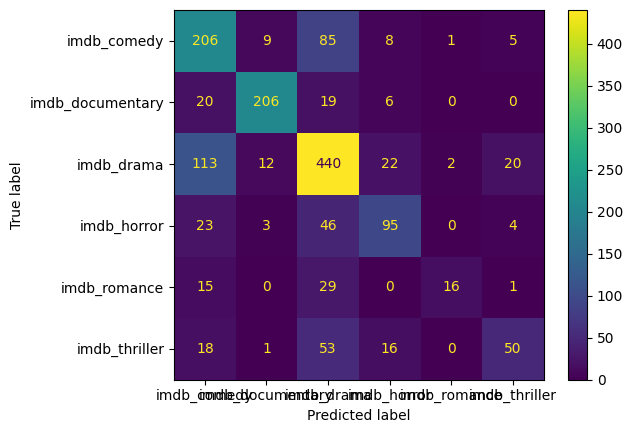

In [34]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)

disp.plot()

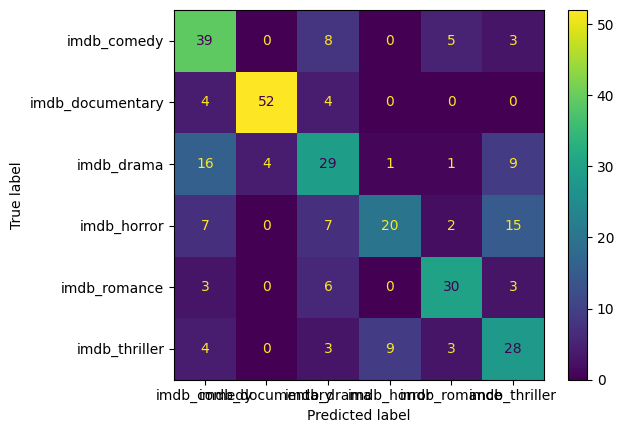

In [35]:
cm_equlibrate = confusion_matrix(y_test_equilibrate, y_pred_equilibrate, labels=model_equilibrate.classes_)
disp_equilibrate = ConfusionMatrixDisplay(confusion_matrix=cm_equlibrate,
                               display_labels=model_equilibrate.classes_)
disp_equilibrate.plot()


## MultinomialNB with unigram and bigram

In [21]:
model = make_pipeline(CountVectorizer(ngram_range = (1,2)), MultinomialNB())

In [22]:
y_train.shape

(6176,)

In [23]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report unbalanced:\n", classification_report(y_test, y_pred))

Features dimension: (6176, 6042430)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.77      0.43      0.55       314
imdb_documentary       0.93      0.79      0.86       251
      imdb_drama       0.51      0.97      0.67       609
     imdb_horror       1.00      0.02      0.03       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.60      1544
       macro avg       0.54      0.37      0.35      1544
    weighted avg       0.62      0.60      0.52      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [24]:
model_equilibrate = make_pipeline(CountVectorizer(ngram_range = (1,2)), MultinomialNB())

In [25]:
model_equilibrate.fit(X_train_equilibrate, y_train_equilibrate)


y_pred_equilibrate = model_equilibrate.predict(X_test_equilibrate)

print(f"Features dimension: {len(X_train_equilibrate), len(model_equilibrate[0].vocabulary_)}")
print("Classification Report balanced:\n", classification_report(y_test_equilibrate, y_pred_equilibrate))

Features dimension: (1257, 1899693)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.40      0.62      0.49        55
imdb_documentary       0.90      0.78      0.84        60
      imdb_drama       1.00      0.02      0.03        60
     imdb_horror       1.00      0.04      0.08        51
    imdb_romance       0.27      0.95      0.42        42
   imdb_thriller       0.31      0.17      0.22        47

        accuracy                           0.42       315
       macro avg       0.65      0.43      0.35       315
    weighted avg       0.68      0.42      0.35       315



## Plotting results MultinomialNB with unigram and bigram

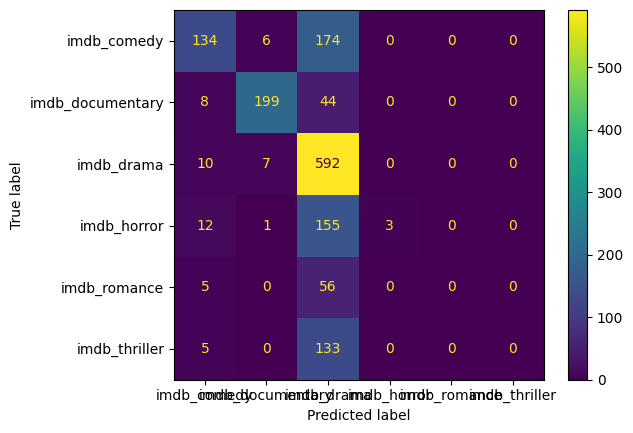

In [26]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)

disp.plot()

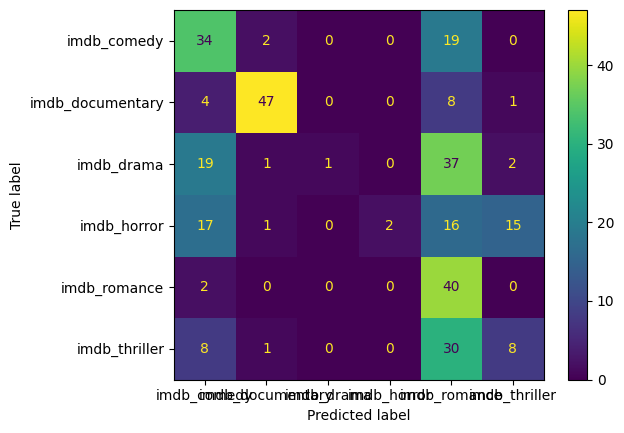

In [27]:
cm_equlibrate = confusion_matrix(y_test_equilibrate, y_pred_equilibrate, labels=model_equilibrate.classes_)
disp_equilibrate = ConfusionMatrixDisplay(confusion_matrix=cm_equlibrate,
                               display_labels=model_equilibrate.classes_)
disp_equilibrate.plot()


## MultinomialNB with bigram

In [28]:
model = make_pipeline(CountVectorizer(ngram_range = (2,2)), MultinomialNB())

In [29]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report unbalanced:\n", classification_report(y_test, y_pred))

Features dimension: (6176, 5841766)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.87      0.33      0.48       314
imdb_documentary       0.93      0.78      0.85       251
      imdb_drama       0.49      0.98      0.66       609
     imdb_horror       1.00      0.01      0.02       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.58      1544
       macro avg       0.55      0.35      0.33      1544
    weighted avg       0.63      0.58      0.50      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [30]:
model_equilibrate = make_pipeline(CountVectorizer(ngram_range = (1,2)), MultinomialNB())

In [31]:
model_equilibrate.fit(X_train_equilibrate, y_train_equilibrate)


y_pred_equilibrate = model_equilibrate.predict(X_test_equilibrate)

print(f"Features dimension: {len(X_train_equilibrate), len(model_equilibrate[0].vocabulary_)}")
print("Classification Report balanced:\n", classification_report(y_test_equilibrate, y_pred_equilibrate))

Features dimension: (1257, 1899693)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.40      0.62      0.49        55
imdb_documentary       0.90      0.78      0.84        60
      imdb_drama       1.00      0.02      0.03        60
     imdb_horror       1.00      0.04      0.08        51
    imdb_romance       0.27      0.95      0.42        42
   imdb_thriller       0.31      0.17      0.22        47

        accuracy                           0.42       315
       macro avg       0.65      0.43      0.35       315
    weighted avg       0.68      0.42      0.35       315



## Plotting results MultinomialNB with bigram

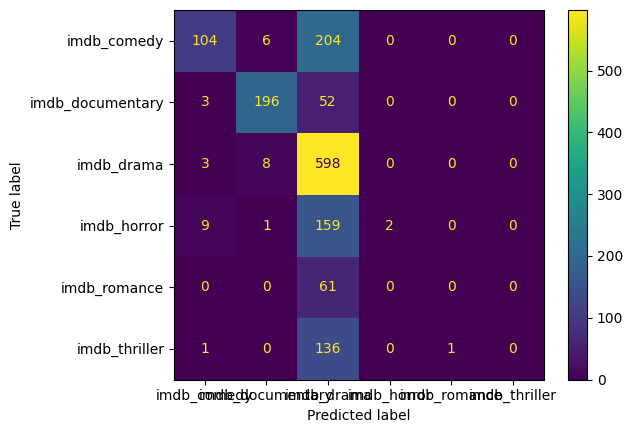

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)

disp.plot()

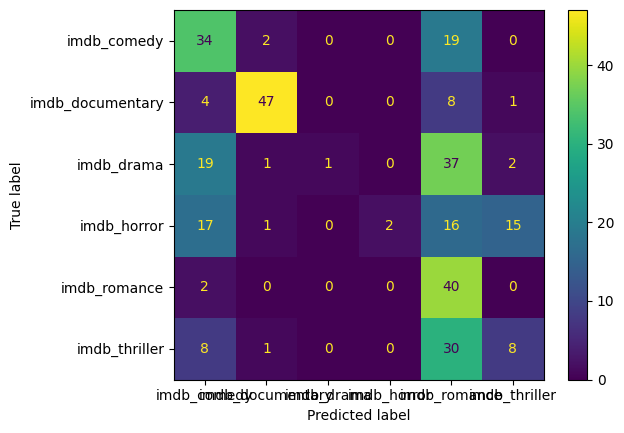

In [33]:
cm_equlibrate = confusion_matrix(y_test_equilibrate, y_pred_equilibrate, labels=model_equilibrate.classes_)
disp_equilibrate = ConfusionMatrixDisplay(confusion_matrix=cm_equlibrate,
                               display_labels=model_equilibrate.classes_)
disp_equilibrate.plot()


## Training MultinomialNB unigram with stop_Word

In [38]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())

In [39]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report unbalanced:\n", classification_report(y_test, y_pred))

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Features dimension: (6176, 200363)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.80      0.84       251
      imdb_drama       0.66      0.73      0.69       609
     imdb_horror       0.62      0.56      0.59       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.67      0.36      0.47       138

        accuracy                           0.65      1544
       macro avg       0.70      0.56      0.59      1544
    weighted avg       0.67      0.65      0.65      1544



In [40]:
model_equilibrate = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())

In [41]:
model_equilibrate.fit(X_train_equilibrate, y_train_equilibrate)


y_pred_equilibrate = model_equilibrate.predict(X_test_equilibrate)

print(f"Features dimension: {len(X_train_equilibrate), len(model_equilibrate[0].vocabulary_)}")
print("Classification Report balanced:\n", classification_report(y_test_equilibrate, y_pred_equilibrate))

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Features dimension: (1257, 83180)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.53      0.76      0.62        55
imdb_documentary       0.92      0.73      0.81        60
      imdb_drama       0.50      0.50      0.50        60
     imdb_horror       0.61      0.37      0.46        51
    imdb_romance       0.69      0.81      0.75        42
   imdb_thriller       0.45      0.45      0.45        47

        accuracy                           0.60       315
       macro avg       0.62      0.60      0.60       315
    weighted avg       0.62      0.60      0.60       315



## Plotting results MultinomialNB with unigram and stopwords

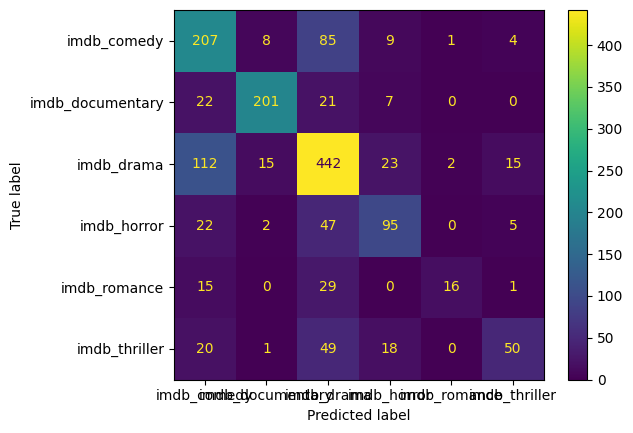

In [42]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)

disp.plot()

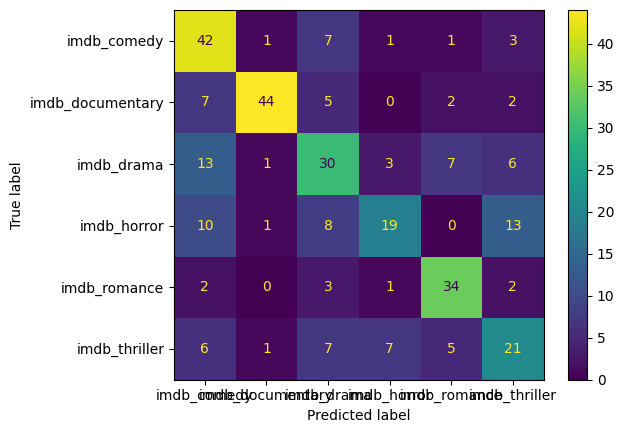

: 

In [ ]:
cm_equlibrate = confusion_matrix(y_test_equilibrate, y_pred_equilibrate, labels=model_equilibrate.classes_)
disp_equilibrate = ConfusionMatrixDisplay(confusion_matrix=cm_equlibrate,
                               display_labels=model_equilibrate.classes_)
disp_equilibrate.plot()
